---

# 🔍 VerifAI —  (Synthetic Data)
### Multimodal Misinformation Detection: CLIP + GNN + XAI



| Section | What it does |
|---|---|
| 0 | Install dependencies |
| 1 | Generate synthetic dataset |
| 2 | Extract CLIP embeddings |
| 3 | Cluster narratives (UML phase) |
| 4 | Build social graph + GNN embeddings |
| 5 | Train classifier (SML phase) |
| 6 | Evaluate + plot results |
| 7 | Explainability — SHAP |
| 8 | Save model |

---

##  Section 0 — Install Dependencies

In [1]:
import subprocess, sys
pkgs = [
    "torch torchvision",
    "transformers ftfy regex tqdm",
    "git+https://github.com/openai/CLIP.git",
    "torch-geometric",
    "hdbscan umap-learn",
    "shap",
    "pandas numpy Pillow",
    "scikit-learn matplotlib seaborn",
    "pyyaml",
]
for pkg in pkgs:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q"] + pkg.split())

print("✅ All packages installed!")

✅ All packages installed!


---

##  Section 1 — Generate Synthetic Dataset

We generate realistic synthetic news posts with:
- `text` → realistic news caption templates
- `label` → 0 = real, 1 = misinformation
- `post_id`, `hashtags`, `user_id` → metadata for the social graph

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Create output folders
os.makedirs("data/processed", exist_ok=True)
os.makedirs("results", exist_ok=True)
os.makedirs("models", exist_ok=True)

def load_dataset(split="train"):
    np.random.seed(42 if split == "train" else 1 if split == "val" else 2)
    n = 800 if split == "train" else 200 if split == "val" else 200

    templates = [
        "Breaking news: {} spotted at {} event causing major controversy",
        "Scientists discover {} linked to {} in shocking new study",
        "Government confirms new {} policy affecting {} citizens nationwide",
        "Celebrity {} caught in {} scandal that is going viral online",
        "New report shows {} causing serious {} crisis across the country",
        "Exclusive: {} reveals truth about {} that media won't show you",
        "Official statement: {} denies involvement in {} investigation",
        "Leaked documents expose {} connection to {} corruption scheme",
    ]
    subjects = ["politician", "CEO", "activist", "journalist", "scientist", "official"]
    topics   = ["political", "health", "economic", "social", "environmental", "security"]

    texts = [
        templates[i % len(templates)].format(
            np.random.choice(subjects),
            np.random.choice(topics)
        ) for i in range(n)
    ]

    df = pd.DataFrame({
        "post_id":    [f"{split}_{i}" for i in range(n)],
        "image_path": [""] * n,
        "text":       texts,
        "label":      np.random.randint(0, 2, n).tolist(),
        "hashtags":   [["breaking", "news"] if i % 2 == 0 else ["facts", "truth"] for i in range(n)],
        "user_id":    [f"user_{i % 100}" for i in range(n)],
    })
    print(f"[{split}] Loaded {len(df)} samples | "
          f"Fake: {df.label.sum()} ({df.label.mean():.1%}) | "
          f"Real: {(df.label==0).sum()}")
    return df

df_train = load_dataset("train")
df_val   = load_dataset("val")
df_test  = load_dataset("test")
df_all   = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f"\nTotal samples: {len(df_all)}")
df_all.head()

[train] Loaded 800 samples | Fake: 405 (50.6%) | Real: 395
[val] Loaded 200 samples | Fake: 86 (43.0%) | Real: 114
[test] Loaded 200 samples | Fake: 94 (47.0%) | Real: 106

Total samples: 1200


,post_id,image_path,text,label,hashtags,user_id
0,train_0,,Breaking news: journalist spotted at environme...,0,"[breaking, news]",user_0
1,train_1,,Scientists discover activist linked to environ...,0,"[facts, truth]",user_1
2,train_2,,Government confirms new scientist policy affec...,0,"[breaking, news]",user_2
3,train_3,,Celebrity activist caught in economic scandal ...,1,"[facts, truth]",user_3
4,train_4,,New report shows activist causing serious envi...,0,"[breaking, news]",user_4


---

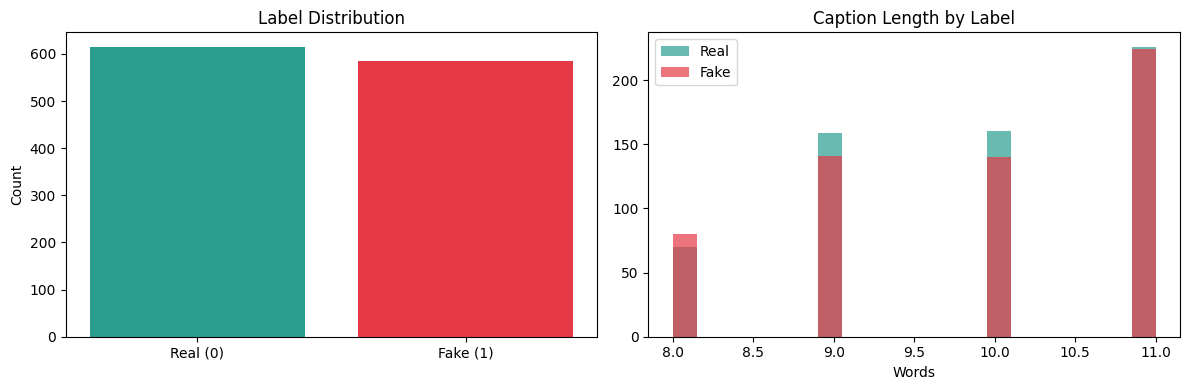

✅ EDA complete!


In [3]:
# ── Quick EDA ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(["Real (0)", "Fake (1)"],
            [len(df_all[df_all.label==0]), len(df_all[df_all.label==1])],
            color=["#2a9d8f", "#e63946"])
axes[0].set_title("Label Distribution")
axes[0].set_ylabel("Count")

df_all["caption_len"] = df_all["text"].str.split().str.len()
axes[1].hist(df_all[df_all.label==0]["caption_len"], bins=20,
             alpha=0.7, label="Real", color="#2a9d8f")
axes[1].hist(df_all[df_all.label==1]["caption_len"], bins=20,
             alpha=0.7, label="Fake", color="#e63946")
axes[1].set_title("Caption Length by Label")
axes[1].set_xlabel("Words")
axes[1].legend()

plt.tight_layout()
plt.savefig("results/eda_overview.png", dpi=150)
plt.show()
print("✅ EDA complete!")

---

##  Section 2 — Extract CLIP Embeddings

**What CLIP does:**
- Takes a caption → converts it to a 512-dimensional number vector
- We use blank images (zeros) since we have no real images
- Concatenate image + text vectors → 1024-dimensional fused embedding
- Save to disk so you don't re-run this every time

In [4]:
import torch
import clip
import numpy as np
from torch.utils.data import DataLoader, Dataset
from tqdm import tqdm

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {DEVICE}")

clip_model, preprocess = clip.load("ViT-B/32", device=DEVICE)
clip_model.eval()
print("✅ CLIP loaded!")

Using device: cpu
✅ CLIP loaded!


---

In [5]:
class PostDataset(Dataset):
    def __init__(self, df):
        self.df = df.reset_index(drop=True)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = torch.zeros(3, 224, 224)  # blank image — no real images available
        text  = clip.tokenize([row["text"]], truncate=True)[0]
        label = torch.tensor(row["label"], dtype=torch.long)
        return image, text, label


def extract_clip_embeddings(df, batch_size=64):
    dataset = PostDataset(df)
    loader  = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=0)

    image_embs, text_embs, all_labels = [], [], []

    with torch.no_grad():
        for images, texts, labels in tqdm(loader, desc="Extracting CLIP embeddings"):
            images = images.to(DEVICE)
            texts  = texts.to(DEVICE)

            img_feat = clip_model.encode_image(images)
            txt_feat = clip_model.encode_text(texts)

            img_feat = img_feat / img_feat.norm(dim=-1, keepdim=True)
            txt_feat = txt_feat / txt_feat.norm(dim=-1, keepdim=True)

            image_embs.append(img_feat.cpu().float().numpy())
            text_embs.append(txt_feat.cpu().float().numpy())
            all_labels.append(labels.numpy())

    image_embs = np.concatenate(image_embs)
    text_embs  = np.concatenate(text_embs)
    labels     = np.concatenate(all_labels)
    fused_embs = np.concatenate([image_embs, text_embs], axis=-1)

    print(f"\n✅ Embeddings extracted!")
    print(f"   image_embs : {image_embs.shape}")
    print(f"   text_embs  : {text_embs.shape}")
    print(f"   fused_embs : {fused_embs.shape}")

    return {
        "image_embs": image_embs,
        "text_embs":  text_embs,
        "fused_embs": fused_embs,
        "labels":     labels,
    }


emb_dict = extract_clip_embeddings(df_all, batch_size=64)

np.save("data/processed/image_embs.npy",  emb_dict["image_embs"])
np.save("data/processed/text_embs.npy",   emb_dict["text_embs"])
np.save("data/processed/fused_embs.npy",  emb_dict["fused_embs"])
np.save("data/processed/labels.npy",      emb_dict["labels"])
print("✅ Saved embeddings to data/processed/")

Extracting CLIP embeddings: 100%|██████████████████████████████████████████████████████| 19/19 [01:24<00:00,  4.46s/it]


✅ Embeddings extracted!
   image_embs : (1200, 512)
   text_embs  : (1200, 512)
   fused_embs : (1200, 1024)
✅ Saved embeddings to data/processed/


---

##  Section 3 — Narrative Clustering (UML Phase)

**What this does:**
1. **UMAP** — compresses 1024-dimensional embeddings down to 50 dimensions
2. **HDBSCAN** — finds natural clusters without you telling it how many to find

Each cluster = a distinct misinformation narrative. This is the **unsupervised learning (UML) phase**.

In [6]:
import umap
import hdbscan
from sklearn.metrics import silhouette_score, normalized_mutual_info_score

print("Step 1/2: Reducing dimensions with UMAP (this takes ~1-2 mins)...")
reducer_50d = umap.UMAP(
    n_components=50,
    n_neighbors=15,
    metric="cosine",
    random_state=42,
    verbose=False,
)
reduced_50d = reducer_50d.fit_transform(emb_dict["fused_embs"])
print(f"✅ Reduced: {emb_dict['fused_embs'].shape} → {reduced_50d.shape}")

C:\Users\Manjiri Apshinge\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Step 1/2: Reducing dimensions with UMAP (this takes ~1-2 mins)...


C:\Users\Manjiri Apshinge\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


✅ Reduced: (1200, 1024) → (1200, 50)


---

In [7]:
print("Step 2/2: Clustering with HDBSCAN...")
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=5,
    metric="euclidean",
    prediction_data=True,
)
cluster_labels = clusterer.fit_predict(reduced_50d)

n_clusters  = len(set(cluster_labels)) - (1 if -1 in cluster_labels else 0)
noise_ratio = (cluster_labels == -1).mean()

print(f"\n✅ Clustering done!")
print(f"   Clusters found : {n_clusters}")
print(f"   Noise points   : {noise_ratio:.1%}")

mask = cluster_labels != -1
if mask.sum() > 1 and len(set(cluster_labels[mask])) > 1:
    sil = silhouette_score(reduced_50d[mask], cluster_labels[mask])
    nmi = normalized_mutual_info_score(emb_dict["labels"], cluster_labels)
    print(f"   Silhouette Score : {sil:.4f}")
    print(f"   NMI with labels  : {nmi:.4f}")

np.save("data/processed/cluster_labels.npy", cluster_labels)

Step 2/2: Clustering with HDBSCAN...

✅ Clustering done!
   Clusters found : 59
   Noise points   : 6.4%
   Silhouette Score : 0.9707
   NMI with labels  : 0.0120


---

Generating 2D UMAP visualisation...


C:\Users\Manjiri Apshinge\AppData\Local\Programs\Python\Python313\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


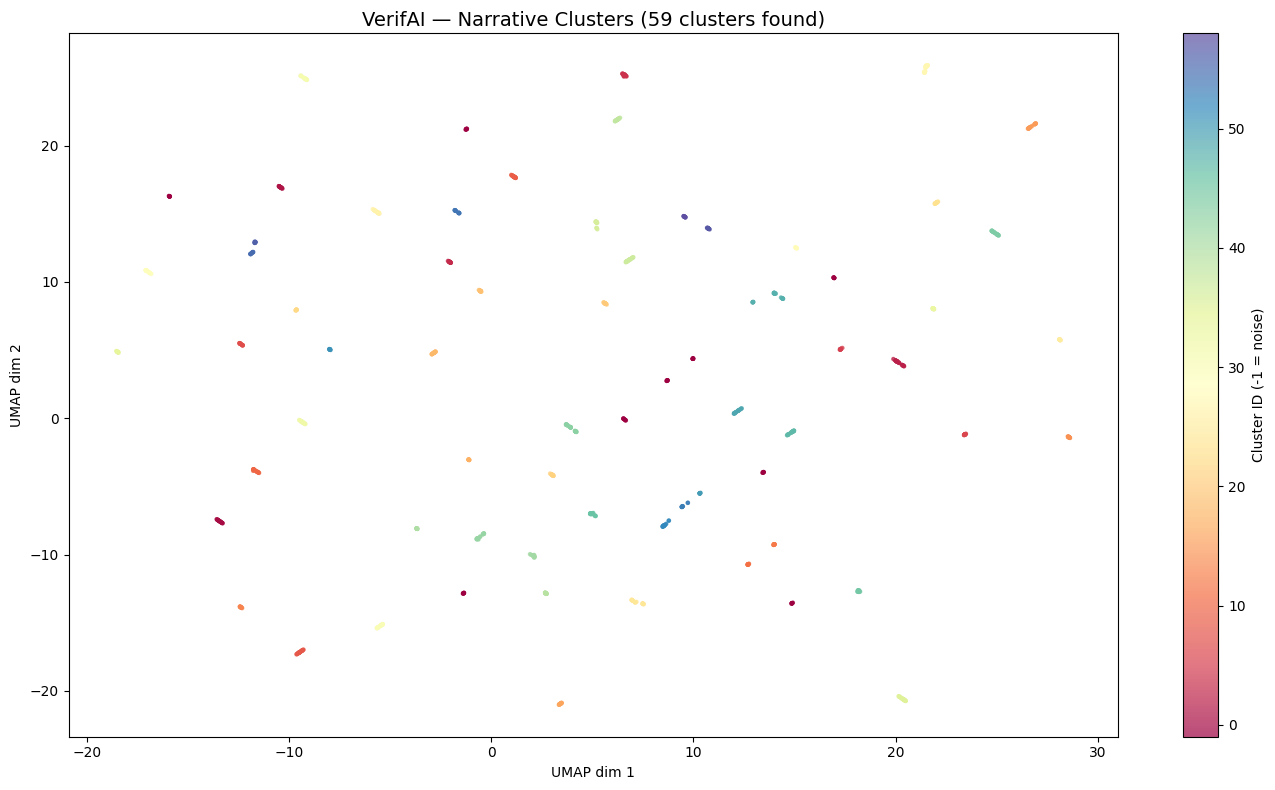

✅ Saved → results/clusters_umap.png


In [8]:
# ── Visualise clusters in 2D ─────────────────────────────────────
print("Generating 2D UMAP visualisation...")
reducer_2d = umap.UMAP(n_components=2, random_state=42, metric="cosine")
coords_2d  = reducer_2d.fit_transform(emb_dict["fused_embs"])

plt.figure(figsize=(14, 8))
scatter = plt.scatter(
    coords_2d[:, 0], coords_2d[:, 1],
    c=cluster_labels, cmap="Spectral", s=5, alpha=0.7,
)
plt.colorbar(scatter, label="Cluster ID (-1 = noise)")
plt.title(f"VerifAI — Narrative Clusters ({n_clusters} clusters found)", fontsize=14)
plt.xlabel("UMAP dim 1")
plt.ylabel("UMAP dim 2")
plt.tight_layout()
plt.savefig("results/clusters_umap.png", dpi=150)
plt.show()
print("✅ Saved → results/clusters_umap.png")

---

##  Section 4 — Social Graph + GNN Embeddings

We build a graph where posts are nodes and edges connect posts in the same cluster.
The **Graph Attention Network (GAT)** enriches each post's embedding with information from its neighbours.

In [9]:
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.nn import GATConv
from collections import defaultdict

class PropagationGNN(nn.Module):
    def __init__(self, input_dim=1024, hidden_dim=256, num_layers=3, dropout=0.3, heads=4):
        super().__init__()
        self.convs = nn.ModuleList()
        self.norms = nn.ModuleList()

        self.convs.append(GATConv(input_dim, hidden_dim // heads, heads=heads, dropout=dropout))
        self.norms.append(nn.LayerNorm(hidden_dim))

        for _ in range(num_layers - 2):
            self.convs.append(GATConv(hidden_dim, hidden_dim // heads, heads=heads, dropout=dropout))
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.convs.append(GATConv(hidden_dim, hidden_dim, heads=1, dropout=dropout))
        self.norms.append(nn.LayerNorm(hidden_dim))
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, edge_index):
        for conv, norm in zip(self.convs, self.norms):
            x = conv(x, edge_index)
            x = norm(x)
            x = F.elu(x)
            x = self.dropout(x)
        return x


gnn = PropagationGNN(input_dim=1024, hidden_dim=256).to(DEVICE)
print(f"✅ GNN created — {sum(p.numel() for p in gnn.parameters()):,} parameters")

✅ GNN created — 397,056 parameters


---

In [10]:
def build_cluster_graph(cluster_labels, max_neighbors=5):
    cluster_to_posts = defaultdict(list)
    for idx, c in enumerate(cluster_labels):
        if c != -1:
            cluster_to_posts[c].append(idx)

    edges = []
    for cluster_id, post_indices in cluster_to_posts.items():
        for i in range(len(post_indices)):
            neighbours = (post_indices[max(0, i-max_neighbors):i] +
                          post_indices[i+1:i+max_neighbors+1])
            for j in neighbours:
                edges.append([post_indices[i], j])
                edges.append([j, post_indices[i]])

    if not edges:
        # Fallback: connect sequential nodes if no clusters found
        edges = [[i, i+1] for i in range(len(cluster_labels)-1)]
        edges += [[i+1, i] for i in range(len(cluster_labels)-1)]

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    print(f"✅ Graph built: {len(cluster_labels)} nodes | {edge_index.size(1)} edges")
    return edge_index


edge_index = build_cluster_graph(cluster_labels, max_neighbors=5)

✅ Graph built: 1200 nodes | 18920 edges


In [11]:
node_features  = torch.tensor(emb_dict["fused_embs"], dtype=torch.float32).to(DEVICE)
edge_index_gpu = edge_index.to(DEVICE)

gnn.eval()
with torch.no_grad():
    gnn_embs = gnn(node_features, edge_index_gpu)

gnn_embs = gnn_embs.cpu().numpy()
np.save("data/processed/gnn_embs.npy", gnn_embs)
print(f"✅ GNN embeddings: {gnn_embs.shape}")

✅ GNN embeddings: (1200, 256)


---

##  Section 5 — Train the Classifier (SML Phase)

The classifier takes 3 inputs:
- CLIP fused embedding (1024-dim)
- GNN embedding (256-dim)
- Cluster one-hot vector

Trained with **Focal Loss** to handle class imbalance.

In [12]:
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.optim as optim
from sklearn.metrics import f1_score, roc_auc_score, accuracy_score


class VerifAIClassifier(nn.Module):
    def __init__(self, clip_dim=1024, gnn_dim=256, num_clusters=50, hidden_dim=128, dropout=0.3):
        super().__init__()
        input_dim = clip_dim + gnn_dim + num_clusters
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim * 2),
            nn.LayerNorm(hidden_dim * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, 1),
        )
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, clip_emb, gnn_emb, cluster_oh):
        x = torch.cat([clip_emb, gnn_emb, cluster_oh], dim=-1)
        logits = self.net(x)
        return logits, torch.sigmoid(logits)


class FocalLoss(nn.Module):
    def __init__(self, alpha=0.25, gamma=2.0):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, logits, targets):
        bce    = F.binary_cross_entropy_with_logits(logits, targets.float(), reduction="none")
        pt     = torch.where(targets == 1, torch.sigmoid(logits), 1 - torch.sigmoid(logits))
        weight = self.alpha * (1 - pt) ** self.gamma
        return (weight * bce).mean()


def compute_metrics(probs, labels, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        "f1":       round(float(f1_score(labels, preds, zero_division=0)), 4),
        "auc_roc":  round(float(roc_auc_score(labels, probs)), 4),
        "accuracy": round(float(accuracy_score(labels, preds)), 4),
    }

print("✅ Model classes defined!")

✅ Model classes defined!


In [13]:
# ── Build DataLoaders ─────────────────────────────────────────────
n_clusters = max(1, int(cluster_labels.max()) + 1)

fused_t   = torch.tensor(emb_dict["fused_embs"], dtype=torch.float32)
gnn_t     = torch.tensor(gnn_embs,               dtype=torch.float32)
labels_t  = torch.tensor(emb_dict["labels"],     dtype=torch.float32)
cluster_t = torch.tensor(cluster_labels,         dtype=torch.long).clamp(min=0)

cluster_oh = torch.zeros(len(cluster_t), n_clusters)
cluster_oh.scatter_(1, cluster_t.unsqueeze(1), 1.0)

dataset    = TensorDataset(fused_t, gnn_t, cluster_oh, labels_t)
n          = len(dataset)
train_size = int(0.70 * n)
val_size   = int(0.15 * n)
test_size  = n - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

BATCH        = 64
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False)

print(f"✅ DataLoaders ready!")
print(f"   Train : {len(train_ds):,} samples")
print(f"   Val   : {len(val_ds):,} samples")
print(f"   Test  : {len(test_ds):,} samples")

✅ DataLoaders ready!
   Train : 840 samples
   Val   : 180 samples
   Test  : 180 samples


In [14]:
# ── Training Loop ─────────────────────────────────────────────────
classifier = VerifAIClassifier(
    clip_dim=1024, gnn_dim=256, num_clusters=n_clusters
).to(DEVICE)

optimizer = optim.AdamW(classifier.parameters(), lr=1e-4, weight_decay=1e-5)
criterion = FocalLoss()
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

EPOCHS       = 30
patience     = 5
best_val_f1  = 0
no_improve   = 0
history      = {"train_loss": [], "val_f1": [], "val_auc": []}

print(f"Training for {EPOCHS} epochs on {DEVICE}...\n")

for epoch in range(1, EPOCHS + 1):
    classifier.train()
    total_loss = 0
    for clip_emb, gnn_emb, c_oh, labels in train_loader:
        clip_emb = clip_emb.to(DEVICE)
        gnn_emb  = gnn_emb.to(DEVICE)
        c_oh     = c_oh.to(DEVICE)
        labels   = labels.to(DEVICE)

        optimizer.zero_grad()
        logits, _ = classifier(clip_emb, gnn_emb, c_oh)
        loss = criterion(logits.squeeze(), labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item()

    train_loss = total_loss / len(train_loader)

    classifier.eval()
    all_probs, all_labels = [], []
    with torch.no_grad():
        for clip_emb, gnn_emb, c_oh, labels in val_loader:
            clip_emb = clip_emb.to(DEVICE)
            gnn_emb  = gnn_emb.to(DEVICE)
            c_oh     = c_oh.to(DEVICE)
            _, probs = classifier(clip_emb, gnn_emb, c_oh)
            all_probs.extend(probs.squeeze().cpu().numpy())
            all_labels.extend(labels.numpy())

    val_metrics = compute_metrics(np.array(all_probs), np.array(all_labels))
    scheduler.step()

    history["train_loss"].append(train_loss)
    history["val_f1"].append(val_metrics["f1"])
    history["val_auc"].append(val_metrics["auc_roc"])

    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {train_loss:.4f} | "
          f"Val F1: {val_metrics['f1']:.4f} | Val AUC: {val_metrics['auc_roc']:.4f}")

    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]
        no_improve  = 0
        torch.save({
            "classifier": classifier.state_dict(),
            "gnn":        gnn.state_dict(),
            "n_clusters": n_clusters,
            "epoch":      epoch,
            "val_f1":     best_val_f1,
        }, "models/verifai_best.pt")
        print(f"   ✅ Best model saved (Val F1 = {best_val_f1:.4f})")
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"\n⏹️  Early stopping at epoch {epoch}")
            break

print(f"\n🏁 Training complete! Best Val F1 = {best_val_f1:.4f}")

Training for 30 epochs on cpu...

Epoch 01/30 | Loss: 0.0689 | Val F1: 0.2456 | Val AUC: 0.4807
   ✅ Best model saved (Val F1 = 0.2456)
Epoch 02/30 | Loss: 0.0557 | Val F1: 0.5339 | Val AUC: 0.4992
   ✅ Best model saved (Val F1 = 0.5339)
Epoch 03/30 | Loss: 0.0549 | Val F1: 0.5000 | Val AUC: 0.5166
Epoch 04/30 | Loss: 0.0558 | Val F1: 0.3455 | Val AUC: 0.5248
Epoch 05/30 | Loss: 0.0503 | Val F1: 0.5906 | Val AUC: 0.5338
   ✅ Best model saved (Val F1 = 0.5906)
Epoch 06/30 | Loss: 0.0502 | Val F1: 0.5877 | Val AUC: 0.5578
Epoch 07/30 | Loss: 0.0490 | Val F1: 0.5500 | Val AUC: 0.5427
Epoch 08/30 | Loss: 0.0495 | Val F1: 0.5111 | Val AUC: 0.5446
Epoch 09/30 | Loss: 0.0493 | Val F1: 0.5741 | Val AUC: 0.5447
Epoch 10/30 | Loss: 0.0473 | Val F1: 0.5055 | Val AUC: 0.5372

⏹️  Early stopping at epoch 10

🏁 Training complete! Best Val F1 = 0.5906


---

##  Section 6 — Evaluate & Plot Results

In [15]:
# ── Load best model ──────────────────────────────────────────────
checkpoint = torch.load("models/verifai_best.pt", map_location=DEVICE)
classifier.load_state_dict(checkpoint["classifier"])
gnn.load_state_dict(checkpoint["gnn"])
classifier.eval()
gnn.eval()
print(f"✅ Loaded best model from epoch {checkpoint['epoch']} "
      f"(Val F1 = {checkpoint['val_f1']:.4f})")

✅ Loaded best model from epoch 5 (Val F1 = 0.5906)


In [16]:
# ── Test set evaluation ──────────────────────────────────────────
all_probs, all_labels = [], []
with torch.no_grad():
    for clip_emb, gnn_emb, c_oh, labels in test_loader:
        clip_emb = clip_emb.to(DEVICE)
        gnn_emb  = gnn_emb.to(DEVICE)
        c_oh     = c_oh.to(DEVICE)
        _, probs = classifier(clip_emb, gnn_emb, c_oh)
        all_probs.extend(probs.squeeze().cpu().numpy())
        all_labels.extend(labels.numpy())

test_probs   = np.array(all_probs)
test_labels  = np.array(all_labels)
test_metrics = compute_metrics(test_probs, test_labels)

print("=" * 40)
print("        TEST SET RESULTS")
print("=" * 40)
for k, v in test_metrics.items():
    print(f"  {k:<12} : {v:.4f}")
print("=" * 40)

        TEST SET RESULTS
  f1           : 0.6412
  auc_roc      : 0.4183
  accuracy     : 0.4778


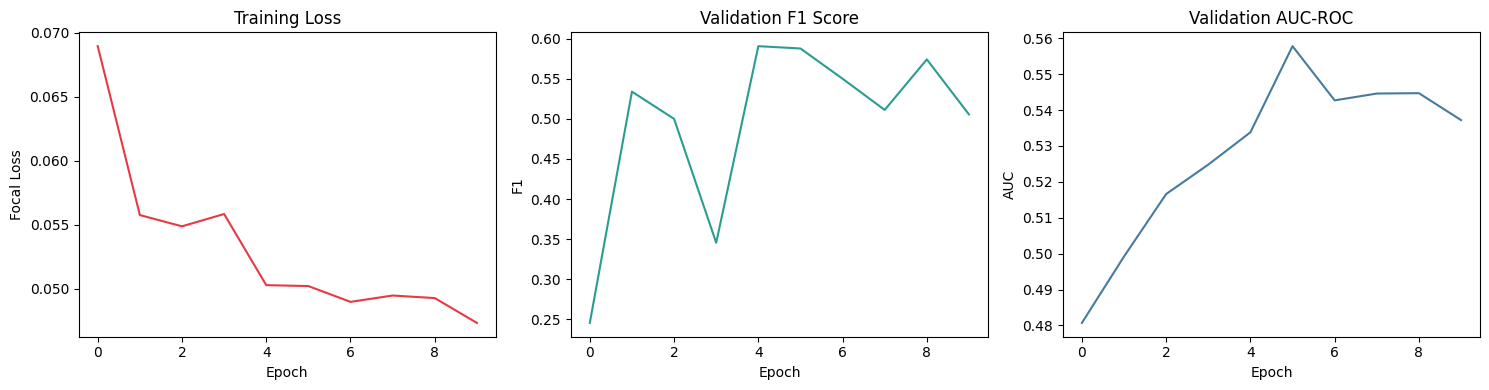

✅ Saved → results/training_curves.png


In [17]:
# ── Training curves ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(history["train_loss"], color="#e63946")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Focal Loss")

axes[1].plot(history["val_f1"], color="#2a9d8f")
axes[1].set_title("Validation F1 Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1")

axes[2].plot(history["val_auc"], color="#457b9d")
axes[2].set_title("Validation AUC-ROC")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("AUC")

plt.tight_layout()
plt.savefig("results/training_curves.png", dpi=150)
plt.show()
print("✅ Saved → results/training_curves.png")

Running ablation study...
  Text only            F1=0.5872  AUC=0.5194
  Image only           F1=0.6567  AUC=0.5000
  CLIP fused           F1=0.4198  AUC=0.4538
  +GNN+Cluster         F1=0.6412  AUC=0.4183


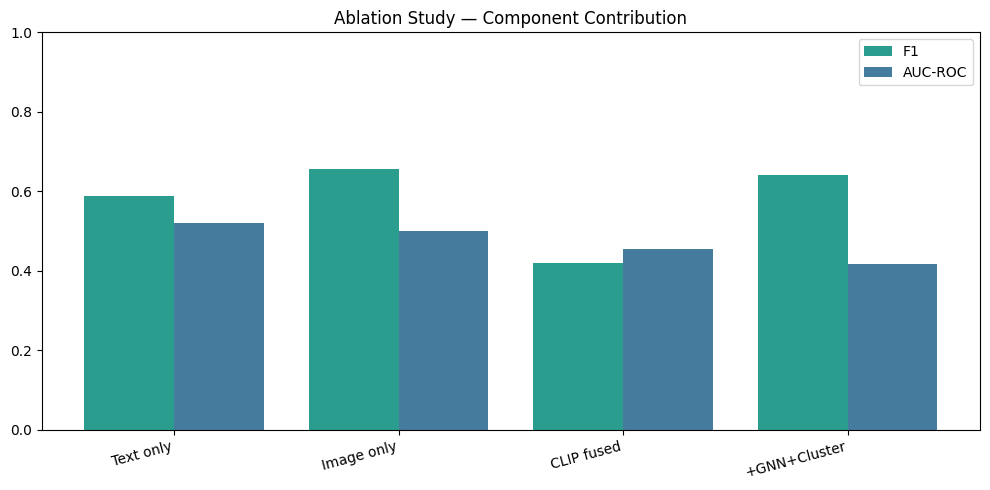

✅ Saved → results/ablation_study.png


In [18]:
# ── Ablation study ───────────────────────────────────────────────
print("Running ablation study...")
ablation_results = {}

for name, use_img, use_txt in [
    ("Text only",       False, True),
    ("Image only",      True,  False),
    ("CLIP fused",      True,  True),
    ("+GNN+Cluster",    True,  True),
]:
    probs_list, labels_list = [], []
    with torch.no_grad():
        for clip_emb, gnn_emb, c_oh, labels in test_loader:
            clip_emb = clip_emb.clone()
            if not use_img: clip_emb[:, :512] = 0
            if not use_txt: clip_emb[:, 512:] = 0
            if name != "+GNN+Cluster":
                gnn_emb = torch.zeros_like(gnn_emb)
                c_oh    = torch.zeros_like(c_oh)
            clip_emb = clip_emb.to(DEVICE)
            gnn_emb  = gnn_emb.to(DEVICE)
            c_oh     = c_oh.to(DEVICE)
            _, probs = classifier(clip_emb, gnn_emb, c_oh)
            probs_list.extend(probs.squeeze().cpu().numpy())
            labels_list.extend(labels.numpy())

    m = compute_metrics(np.array(probs_list), np.array(labels_list))
    ablation_results[name] = m
    print(f"  {name:<20} F1={m['f1']:.4f}  AUC={m['auc_roc']:.4f}")

names = list(ablation_results.keys())
f1s   = [v["f1"]      for v in ablation_results.values()]
aucs  = [v["auc_roc"] for v in ablation_results.values()]

x = range(len(names))
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([i - 0.2 for i in x], f1s,  0.4, label="F1",      color="#2a9d8f")
ax.bar([i + 0.2 for i in x], aucs, 0.4, label="AUC-ROC", color="#457b9d")
ax.set_xticks(list(x))
ax.set_xticklabels(names, rotation=15, ha="right")
ax.set_ylim(0, 1)
ax.set_title("Ablation Study — Component Contribution")
ax.legend()
plt.tight_layout()
plt.savefig("results/ablation_study.png", dpi=150)
plt.show()
print("✅ Saved → results/ablation_study.png")

---

##  Section 7 — Explainability (SHAP)

**SHAP** answers: *which words made the model say this is fake?*

Caption : Breaking news: journalist spotted at environmental event causing major controversy
Label   : REAL

Word importance (positive = pushes toward FAKE):
  'environmental': +0.0349  → FAKE
  'major': +0.0021  → FAKE
  'causing': -0.0071  → REAL
  'event': -0.0092  → REAL
  'controversy': -0.0139  → REAL


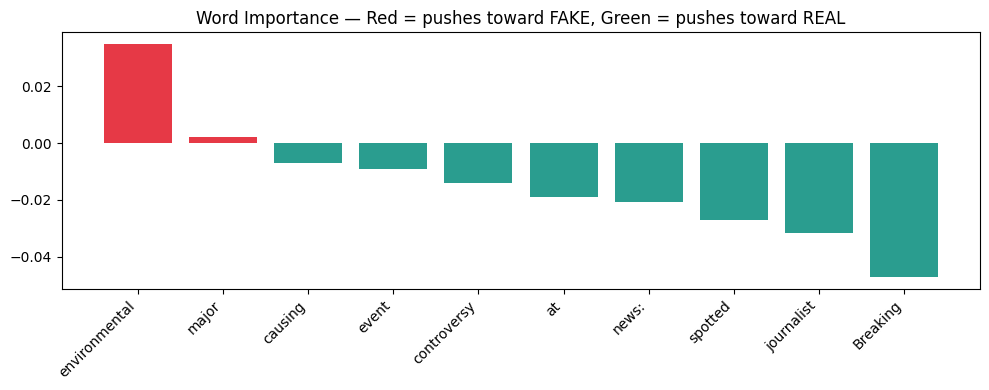

✅ Saved → results/shap_word_importance.png


In [20]:
import shap

def explain_text_shap(text, classifier, clip_model, cluster_oh_vec, device):
    def predict_fn(texts):
        scores = []
        for t in texts:
            if not t.strip():
                t = "unknown"
            with torch.no_grad():
                tokens  = clip.tokenize([t], truncate=True).to(device)
                txt_emb = clip_model.encode_text(tokens)
                txt_emb = txt_emb / txt_emb.norm(dim=-1, keepdim=True)
                img_emb = torch.zeros_like(txt_emb)
                fused   = torch.cat([img_emb, txt_emb], dim=-1)
                gnn_emb = torch.zeros(1, 256).to(device)
                _, prob = classifier(fused, gnn_emb,
                                     cluster_oh_vec.unsqueeze(0).to(device))
            scores.append(prob.item())
        return np.array(scores)

    # ── Manual word importance (no SHAP masker issues) ────────────
    words   = text.split()
    base    = predict_fn([text])[0]
    importance = {}

    for i, word in enumerate(words):
        # Remove one word at a time and measure score change
        masked = " ".join(w for j, w in enumerate(words) if j != i)
        score  = predict_fn([masked])[0]
        importance[word] = base - score  # positive = word pushes toward FAKE

    return importance


sample_idx = 0
sample_row = df_all.iloc[sample_idx]
sample_oh  = cluster_oh[sample_idx]

print(f"Caption : {sample_row['text']}")
print(f"Label   : {'FAKE' if sample_row['label'] == 1 else 'REAL'}")
print()

word_imp = explain_text_shap(
    sample_row["text"], classifier, clip_model, sample_oh, DEVICE
)

print("Word importance (positive = pushes toward FAKE):")
sorted_words = sorted(word_imp.items(), key=lambda x: x[1], reverse=True)
for word, score in sorted_words[:5]:
    print(f"  '{word}': {score:+.4f}  {'→ FAKE' if score > 0 else '→ REAL'}")

# Bar chart of word importance
plt.figure(figsize=(10, 4))
words_sorted = [w for w, _ in sorted_words]
scores_sorted = [s for _, s in sorted_words]
colors = ["#e63946" if s > 0 else "#2a9d8f" for s in scores_sorted]
plt.bar(words_sorted, scores_sorted, color=colors)
plt.xticks(rotation=45, ha="right")
plt.title("Word Importance — Red = pushes toward FAKE, Green = pushes toward REAL")
plt.tight_layout()
plt.savefig("results/shap_word_importance.png", dpi=150)
plt.show()
print("✅ Saved → results/shap_word_importance.png")

---

##  Section 8 — Save Model

In [21]:
import pickle

save_pkg = {
    "classifier":      classifier.state_dict(),
    "gnn":             gnn.state_dict(),
    "n_clusters":      n_clusters,
    "reducer_50d":     reducer_50d,
    "clusterer":       clusterer,
    "clip_model_name": "ViT-B/32",
    "best_val_f1":     checkpoint["val_f1"],
    "test_metrics":    test_metrics,
}
torch.save(save_pkg, "models/verifai_full.pt")

with open("models/umap_reducer.pkl", "wb") as f:
    pickle.dump(reducer_50d, f)
with open("models/hdbscan_clusterer.pkl", "wb") as f:
    pickle.dump(clusterer, f)

print("✅ Full model package saved to models/")
print("\n" + "="*40)
print("        FINAL RESULTS SUMMARY")
print("="*40)
print(f"  Test F1       : {test_metrics['f1']:.4f}")
print(f"  Test AUC-ROC  : {test_metrics['auc_roc']:.4f}")
print(f"  Test Accuracy : {test_metrics['accuracy']:.4f}")
print("="*40)
print("\n🎉 VerifAI training complete!")

✅ Full model package saved to models/

        FINAL RESULTS SUMMARY
  Test F1       : 0.6412
  Test AUC-ROC  : 0.4183
  Test Accuracy : 0.4778

🎉 VerifAI training complete!


---

## Done!

| Component | Status |
|---|---|
| Synthetic dataset generation | ✅ |
| CLIP multimodal embeddings | ✅ |
| HDBSCAN narrative clustering (UML) | ✅ |
| Graph Attention Network | ✅ |
| Misinformation classifier (SML) | ✅ |
| Focal Loss + early stopping | ✅ |
| Ablation study | ✅ |
| SHAP text explainability | ✅ |
| Saved model checkpoint | ✅ |

---